In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lightgbm import LGBMRegressor, LGBMClassifier
import sys
import re
from sklearn.preprocessing import LabelEncoder
import plotly.express as px
from scipy.stats import spearmanr

In [2]:
df_sold = pd.read_csv("../data/Sold/sold_transactions.csv")
df_sold.head()

C:\Users\mayab\AppData\Local\Temp\ipykernel_9620\4086709524.py:1: DtypeWarning: Columns (0: BuyerAgentAOR, 1: ListAgentAOR, 2: WaterfrontYN, 3: ListAgentEmail, 4: OriginatingSystemName, 5: OriginatingSystemSubName, 6: BuyerAgencyCompensationType, 7: latfilled, 8: lonfilled) have mixed types. Specify dtype option on import or set low_memory=False.
  df_sold = pd.read_csv("../data/Sold/sold_transactions.csv")


,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,OriginatingSystemName,OriginatingSystemSubName,BuyerAgencyCompensationType,BuyerAgencyCompensation,latfilled,lonfilled,Year
0,Mlslistings,Mlslistings,"Carpet,Tile,Wood",True,NaN,NaN,False,499000.0,551985747,jwachter@cbnorcal.com,...,6472.0,NaN,NaN,CRMLS,CRMLS_MLSL,NaN,NaN,NaN,NaN,2024
1,HighDesert,HighDesert,NaN,NaN,NaN,NaN,NaN,0.0,535486633,eabrown@lee-associates.com,...,NaN,52320.0,NaN,CRMLS,CRMLS_CRM,NaN,NaN,NaN,NaN,2024
2,OrangeCounty,OrangeCounty,NaN,True,NaN,NaN,NaN,75000.0,529986282,Joe@9WINWIN.com,...,NaN,217364.0,NaN,CRMLS,CRMLS_CRM,NaN,NaN,NaN,NaN,2024
3,InlandValleys,InlandValleys,NaN,True,NaN,NaN,NaN,199000.0,529618166,carolthefinder@yahoo.com,...,NaN,217800.0,NaN,CRMLS,CRMLS_CRM,NaN,NaN,NaN,NaN,2024
4,SouthwestRiversideCounty,SouthwestRiversideCounty,NaN,True,NaN,NaN,NaN,19500.0,522614340,jtavisola@tavisola.com,...,0.0,108883.0,NaN,CRMLS,CRMLS_CRM,NaN,NaN,NaN,NaN,2024


##### Number of Rows and Columns

In [3]:
df_sold.shape

(615376, 85)

The the sold transactions file has 591115 rows and 87 columns.

##### Review column data types

In [4]:
df_sold.info()

<class 'pandas.DataFrame'>
RangeIndex: 615376 entries, 0 to 615375
Data columns (total 85 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   BuyerAgentAOR                 541725 non-null  str    
 1   ListAgentAOR                  547321 non-null  str    
 2   Flooring                      361626 non-null  str    
 3   ViewYN                        553795 non-null  object 
 4   WaterfrontYN                  338 non-null     object 
 5   BasementYN                    10149 non-null   object 
 6   PoolPrivateYN                 538558 non-null  object 
 7   OriginalListPrice             613592 non-null  float64
 8   ListingKey                    615376 non-null  int64  
 9   ListAgentEmail                571926 non-null  str    
 10  CloseDate                     615376 non-null  str    
 11  ClosePrice                    615369 non-null  float64
 12  ListAgentFirstName            611828 non-null  str    


In [5]:
df_sold.columns

Index(['BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'ViewYN', 'WaterfrontYN',
       'BasementYN', 'PoolPrivateYN', 'OriginalListPrice', 'ListingKey',
       'ListAgentEmail', 'CloseDate', 'ClosePrice', 'ListAgentFirstName',
       'ListAgentLastName', 'Latitude', 'Longitude', 'UnparsedAddress',
       'PropertyType', 'LivingArea', 'ListPrice', 'DaysOnMarket',
       'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName',
       'ListAgentFullName', 'CoListAgentFirstName', 'CoListAgentLastName',
       'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName',
       'FireplacesTotal', 'AssociationFeeFrequency', 'AboveGradeFinishedArea',
       'ListingKeyNumeric', 'MLSAreaMajor', 'TaxAnnualAmount',
       'CountyOrParish', 'MlsStatus', 'ElementarySchool', 'AttachedGarageYN',
       'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres',
       'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'StreetNumberNumeric',
       'ListingId', 'BathroomsTotalInteger', 'City', '

In [6]:
df_sold.isna().sum()

BuyerAgentAOR                   73651
ListAgentAOR                    68055
Flooring                       253750
ViewYN                          61581
WaterfrontYN                   615038
                                ...  
BuyerAgencyCompensationType    547629
BuyerAgencyCompensation        547596
latfilled                      519583
lonfilled                      519583
Year                                0
Length: 85, dtype: int64

#### **Missing Value Analysis**

##### Calculate missing counts and percentages per column

In [7]:
missing_sold_counts = df_sold.isnull().sum()
missing_sold_counts

BuyerAgentAOR                   73651
ListAgentAOR                    68055
Flooring                       253750
ViewYN                          61581
WaterfrontYN                   615038
                                ...  
BuyerAgencyCompensationType    547629
BuyerAgencyCompensation        547596
latfilled                      519583
lonfilled                      519583
Year                                0
Length: 85, dtype: int64

In [8]:
missing_sold_percent = (df_sold.isnull().mean()) * 100
missing_sold_percent

BuyerAgentAOR                  11.968455
ListAgentAOR                   11.059092
Flooring                       41.234952
ViewYN                         10.007053
WaterfrontYN                   99.945074
                                 ...    
BuyerAgencyCompensationType    88.990958
BuyerAgencyCompensation        88.985596
latfilled                      84.433420
lonfilled                      84.433420
Year                            0.000000
Length: 85, dtype: float64

In [9]:
missing_summary = pd.DataFrame({
    "missing_sold_counts": missing_sold_counts,
    "missing_sold_percent": missing_sold_percent
})

In [10]:
missing_sold_summary = missing_summary.sort_values(by="missing_sold_percent", ascending=False)
print(missing_sold_summary)

                              missing_sold_counts  missing_sold_percent
MiddleOrJuniorSchoolDistrict               615376                 100.0
ElementarySchoolDistrict                   615376                 100.0
CoveredSpaces                              615376                 100.0
FireplacesTotal                            615376                 100.0
AboveGradeFinishedArea                     615376                 100.0
...                                           ...                   ...
CountyOrParish                                  0                   0.0
ListOfficeName                                  0                   0.0
MlsStatus                                       0                   0.0
StateOrProvince                                 0                   0.0
Year                                            0                   0.0

[85 rows x 2 columns]


In [11]:
missing_sold_summary = missing_sold_summary[missing_sold_summary["missing_sold_counts"] > 0]
print(missing_sold_summary)

                              missing_sold_counts  missing_sold_percent
MiddleOrJuniorSchoolDistrict               615376            100.000000
ElementarySchoolDistrict                   615376            100.000000
CoveredSpaces                              615376            100.000000
FireplacesTotal                            615376            100.000000
AboveGradeFinishedArea                     615376            100.000000
...                                           ...                   ...
ListAgentFullName                             172              0.027950
PostalCode                                    168              0.027300
ListingContractDate                            86              0.013975
ListAgentLastName                              61              0.009913
ClosePrice                                      7              0.001138

[74 rows x 2 columns]


In [12]:
missing_sold_summary["missing_sold_percent"] = missing_sold_summary["missing_sold_percent"].round(2)
print(missing_sold_summary)

                              missing_sold_counts  missing_sold_percent
MiddleOrJuniorSchoolDistrict               615376                100.00
ElementarySchoolDistrict                   615376                100.00
CoveredSpaces                              615376                100.00
FireplacesTotal                            615376                100.00
AboveGradeFinishedArea                     615376                100.00
...                                           ...                   ...
ListAgentFullName                             172                  0.03
PostalCode                                    168                  0.03
ListingContractDate                            86                  0.01
ListAgentLastName                              61                  0.01
ClosePrice                                      7                  0.00

[74 rows x 2 columns]


In [13]:
missing_above_90 = missing_sold_summary[missing_sold_summary['missing_sold_percent'] > 90]
print(missing_above_90)

                              missing_sold_counts  missing_sold_percent
MiddleOrJuniorSchoolDistrict               615376                100.00
ElementarySchoolDistrict                   615376                100.00
CoveredSpaces                              615376                100.00
FireplacesTotal                            615376                100.00
AboveGradeFinishedArea                     615376                100.00
WaterfrontYN                               615038                 99.95
TaxYear                                    614997                 99.94
BusinessType                               613695                 99.73
TaxAnnualAmount                            612791                 99.58
BelowGradeFinishedArea                     612657                 99.56
BasementYN                                 605227                 98.35
BuilderName                                591964                 96.20
LotSizeDimensions                          583070               

In [14]:
missing_above_70 = missing_sold_summary[missing_sold_summary['missing_sold_percent'] > 70]
print(missing_above_70)

                              missing_sold_counts  missing_sold_percent
MiddleOrJuniorSchoolDistrict               615376                100.00
ElementarySchoolDistrict                   615376                100.00
CoveredSpaces                              615376                100.00
FireplacesTotal                            615376                100.00
AboveGradeFinishedArea                     615376                100.00
WaterfrontYN                               615038                 99.95
TaxYear                                    614997                 99.94
BusinessType                               613695                 99.73
TaxAnnualAmount                            612791                 99.58
BelowGradeFinishedArea                     612657                 99.56
BasementYN                                 605227                 98.35
BuilderName                                591964                 96.20
LotSizeDimensions                          583070               

In [15]:
missing_above_70.shape

(28, 2)

In [16]:
missing_above_70

,missing_sold_counts,missing_sold_percent
MiddleOrJuniorSchoolDistrict,615376,100.00
ElementarySchoolDistrict,615376,100.00
CoveredSpaces,615376,100.00
FireplacesTotal,615376,100.00
AboveGradeFinishedArea,615376,100.00
WaterfrontYN,615038,99.95
TaxYear,614997,99.94
BusinessType,613695,99.73
TaxAnnualAmount,612791,99.58
BelowGradeFinishedArea,612657,99.56


Dropping Variables:
- CoveredSpaces                              
- AboveGradeFinishedArea                     
- MiddleOrJuniorSchoolDistrict               
- ElementarySchoolDistrict                   
- FireplacesTotal                            
- WaterfrontYN                               
- TaxYear                                   
- BusinessType                               
- TaxAnnualAmount                            
- BelowGradeFinishedArea                     
- BasementYN                                 
- BuilderName                                
- LotSizeDimensions                          
- CoBuyerAgentFirstName 
- OriginatingSystemName	
- OriginatingSystemSubName	
- ElementarySchool	
- MiddleOrJuniorSchool	
- BuyerAgencyCompensationType
- BuyerAgencyCompensation	
- BuildingAreaTotal	
- HighSchool	
- latfilled	
- lonfilled	
- CoListAgentFirstName	
- CoListAgentLastName	
- CoListOfficeName	
- AssociationFeeFrequency	

To perserve the variables, it would be sufficient if each variable contain less than 70% of missing values in order to use imputation to replace the missingness in the data. 

So, variables with 70% of missing variables will be removed from the dataset because through imputation with variables with a significant number of missingness, it may contribute to bias towards certain values than others. 

In [17]:
df_sold_clean = df_sold.drop(columns=['CoveredSpaces',
'AboveGradeFinishedArea',	
'MiddleOrJuniorSchoolDistrict',
'ElementarySchoolDistrict',
'FireplacesTotal',
'WaterfrontYN',
'TaxYear',
'BusinessType',
'TaxAnnualAmount',	
'BelowGradeFinishedArea',
'BasementYN',	
'BuilderName',	
'LotSizeDimensions',	
'CoBuyerAgentFirstName',	
'OriginatingSystemName',	
'OriginatingSystemSubName',	
'ElementarySchool',	
'MiddleOrJuniorSchool',	
'BuyerAgencyCompensationType',
'BuyerAgencyCompensation',	
'BuildingAreaTotal',	
'HighSchool',	
'latfilled',	
'lonfilled',	
'CoListAgentFirstName',	
'CoListAgentLastName',
'CoListOfficeName',
'AssociationFeeFrequency'	])

In [18]:
df_sold_clean.shape

(615376, 57)

In [19]:
# Calculate percentage for all columns
missing_pct = (df_sold_clean.isna().sum() / len(df_sold_clean)) * 100

# Filter to show only columns that actually have missing data
print(missing_pct[missing_pct > 0].sort_values(ascending=False))

SubdivisionName             64.681756
MainLevelBedrooms           46.923019
Flooring                    41.234952
HighSchoolDistrict          33.387392
AssociationFee              30.966596
AttachedGarageYN            27.743688
Stories                     19.941142
Levels                      13.677491
GarageSpaces                12.785516
PoolPrivateYN               12.483100
BuyerAgentAOR               11.968455
NewConstructionYN           11.872416
ListAgentAOR                11.059092
MLSAreaMajor                11.007904
ViewYN                      10.007053
LotSizeAcres                 9.432282
LotSizeSquareFeet            9.192266
LotSizeArea                  9.115728
FireplaceYN                  8.718085
PropertySubType              7.643457
ListAgentEmail               7.060724
LivingArea                   7.031473
BedroomsTotal                6.632530
BathroomsTotalInteger        4.609215
BuyerOfficeAOR               4.506188
YearBuilt                    4.201821
ParkingTotal

In [20]:
num_cols_with_missing = df_sold_clean.isna().any().sum()

print(f"Number of variables with missing values: {num_cols_with_missing}")

Number of variables with missing values: 46


In [21]:
cols_rows_dropping = missing_pct[(missing_pct < 1) & (missing_pct > 0)]
cols_rows_dropping

OriginalListPrice           0.289904
ClosePrice                  0.001138
ListAgentFirstName          0.576558
ListAgentLastName           0.009913
UnparsedAddress             0.154702
ListPrice                   0.153077
ListAgentFullName           0.027950
BuyerAgentMlsId             0.315092
BuyerAgentFirstName         0.438269
BuyerAgentLastName          0.056226
StreetNumberNumeric         0.249116
City                        0.071664
ContractStatusChangeDate    0.115702
ListingContractDate         0.013975
PostalCode                  0.027300
dtype: float64

In [22]:
cols_rows_dropped = ['OriginalListPrice', 'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'UnparsedAddress', 'ListPrice', 'ListAgentFullName', 'BuyerAgentMlsId',
                'BuyerAgentFirstName', 'BuyerAgentLastName', 'StreetNumberNumeric', 'City', 'ContractStatusChangeDate', 'ListingContractDate', 'PostalCode']

In [23]:
df_sold_clean = df_sold_clean.dropna(subset=['OriginalListPrice', 'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'UnparsedAddress', 'ListPrice', 'ListAgentFullName', 'BuyerAgentMlsId',
                'BuyerAgentFirstName', 'BuyerAgentLastName', 'StreetNumberNumeric', 'City', 'ContractStatusChangeDate', 'ListingContractDate', 'PostalCode'])

In [24]:
df_sold_clean.shape

(603302, 57)

In [25]:
df_sold_clean.shape[0] - df_sold_clean.shape[0]

0

In [26]:
# Calculate percentage for all columns
missing_pct = (df_sold_clean.isna().sum() / len(df_sold_clean)) * 100

# Filter to show only columns that actually have missing data
print(missing_pct[missing_pct > 0].sort_values(ascending=False))

SubdivisionName          64.406384
MainLevelBedrooms        46.149027
Flooring                 41.192139
HighSchoolDistrict       33.404331
AssociationFee           30.424232
AttachedGarageYN         27.718290
Stories                  18.975405
Levels                   12.640601
GarageSpaces             12.623031
BuyerAgentAOR            11.950731
NewConstructionYN        11.658672
PoolPrivateYN            11.519604
ListAgentAOR             11.048198
MLSAreaMajor             10.960514
ViewYN                    9.801559
LotSizeAcres              9.375238
LotSizeSquareFeet         9.133734
LotSizeArea               9.059145
FireplaceYN               8.477512
PropertySubType           7.546304
ListAgentEmail            7.064455
LivingArea                6.818310
BedroomsTotal             6.386685
BathroomsTotalInteger     4.506201
BuyerOfficeAOR            4.382051
YearBuilt                 4.104578
ParkingTotal              2.950927
Latitude                  2.882967
Longitude           

In [27]:
# Create a reference mapping of Names -> Emails
# Drop any rows that have missing emails so the map is 'clean'
email_lookup = df_sold_clean.dropna(subset=['ListAgentEmail']).drop_duplicates(['ListAgentFirstName', 'ListAgentLastName'])

# Set the names as the index to make the 'lookup' possible
email_lookup = email_lookup.set_index(['ListAgentFirstName', 'ListAgentLastName'])['ListAgentEmail']

# Create a function to apply the logic
def fill_missing_emails(row):
    # Only try to fill if the current email is missing
    if pd.isna(row['ListAgentEmail']):
        # Look up the name in our reference map
        return email_lookup.get((row['ListAgentFirstName'], row['ListAgentLastName']), "None")
    return row['ListAgentEmail']

# Apply it to the dataframe
df_sold_clean['ListAgentEmail'] = df_sold_clean.apply(fill_missing_emails, axis=1)

In [28]:
df_sold_clean['ListAgentEmail'].isna().sum()

np.int64(0)

In [29]:
(df_sold_clean['ListAgentEmail'] == 'None').sum()

np.int64(2249)

From the code above, I noticed that there are no missing values for list agent's first and last names, so to determine their emails, I tried to look up any matches by full name to get the list agent's emails for the rows that are missing them. If there are no matches, those emails will be preserved by having a value of "None" (i.e. no email provided).

In [30]:
df_sold_clean.isna().sum()

BuyerAgentAOR                72099
ListAgentAOR                 66654
Flooring                    248513
ViewYN                       59133
PoolPrivateYN                69498
OriginalListPrice                0
ListingKey                       0
ListAgentEmail                   0
CloseDate                        0
ClosePrice                       0
ListAgentFirstName               0
ListAgentLastName                0
Latitude                     17393
Longitude                    17225
UnparsedAddress                  0
PropertyType                     0
LivingArea                   41135
ListPrice                        0
DaysOnMarket                     0
ListOfficeName                   0
BuyerOfficeName               6768
ListAgentFullName                0
BuyerAgentMlsId                  0
BuyerAgentFirstName              0
BuyerAgentLastName               0
ListingKeyNumeric                0
MLSAreaMajor                 66125
CountyOrParish                   0
MlsStatus           

In [31]:
df_sold_clean.columns

Index(['BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'ViewYN', 'PoolPrivateYN',
       'OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude',
       'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName',
       'ListAgentFullName', 'BuyerAgentMlsId', 'BuyerAgentFirstName',
       'BuyerAgentLastName', 'ListingKeyNumeric', 'MLSAreaMajor',
       'CountyOrParish', 'MlsStatus', 'AttachedGarageYN', 'ParkingTotal',
       'PropertySubType', 'LotSizeAcres', 'SubdivisionName', 'BuyerOfficeAOR',
       'YearBuilt', 'StreetNumberNumeric', 'ListingId',
       'BathroomsTotalInteger', 'City', 'BedroomsTotal',
       'ContractStatusChangeDate', 'PurchaseContractDate',
       'ListingContractDate', 'StateOrProvince', 'FireplaceYN', 'Stories',
       'Levels', 'LotSizeArea', 'MainLevelBedrooms', 'NewConstructionYN',
       'GarageSpaces

#### **Convert date fields to datetime format (CloseDate, PurchaseContractDate, ListingContractDate, ContractStatusChangeDate)**

In [32]:
df_sold_clean['CloseDate'] = pd.to_datetime(df_sold_clean['CloseDate'], errors='coerce')

In [33]:
df_sold_clean['PurchaseContractDate'] = pd.to_datetime(df_sold_clean['PurchaseContractDate'], errors='coerce')

In [34]:
df_sold_clean['ListingContractDate'] = pd.to_datetime(df_sold_clean['ListingContractDate'], errors='coerce')

In [35]:
df_sold_clean['ContractStatusChangeDate'] = pd.to_datetime(df_sold_clean['ContractStatusChangeDate'], errors='coerce')

In [36]:
print(df_sold_clean['PurchaseContractDate'].dtype)

datetime64[us]


#### **Remove unnecessary or redundant columns**

In [37]:
df_sold_clean.columns

Index(['BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'ViewYN', 'PoolPrivateYN',
       'OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude',
       'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName',
       'ListAgentFullName', 'BuyerAgentMlsId', 'BuyerAgentFirstName',
       'BuyerAgentLastName', 'ListingKeyNumeric', 'MLSAreaMajor',
       'CountyOrParish', 'MlsStatus', 'AttachedGarageYN', 'ParkingTotal',
       'PropertySubType', 'LotSizeAcres', 'SubdivisionName', 'BuyerOfficeAOR',
       'YearBuilt', 'StreetNumberNumeric', 'ListingId',
       'BathroomsTotalInteger', 'City', 'BedroomsTotal',
       'ContractStatusChangeDate', 'PurchaseContractDate',
       'ListingContractDate', 'StateOrProvince', 'FireplaceYN', 'Stories',
       'Levels', 'LotSizeArea', 'MainLevelBedrooms', 'NewConstructionYN',
       'GarageSpaces

In [38]:
df_sold_clean.shape

(603302, 57)

In [39]:
(df_sold_clean['OriginalListPrice'] == df_sold_clean['ListPrice']).value_counts()

True     410760
False    192542
Name: count, dtype: int64

No redundant columns

#### **Outlier Cleaning**

Remove or flag invalid numeric values: ClosePrice <=0, LivingArea <=0, DaysOnMarket < 0, negative Bedrooms or Bathrooms

Removing and inspecting negative values

In [40]:
neg_counts = (df_sold_clean.select_dtypes(include='number') < 0).sum()

In [41]:
neg_counts[neg_counts > 0]

Latitude             5
Longitude       585969
DaysOnMarket        60
ParkingTotal        95
dtype: int64

In [42]:
(neg_counts[neg_counts > 0] / df_sold_clean.shape[0] * 100).sort_values(ascending=False)

Longitude       97.126978
ParkingTotal     0.015747
DaysOnMarket     0.009945
Latitude         0.000829
dtype: float64

ParkingTotal

In [43]:
neg_ParkingTotal = df_sold_clean[df_sold_clean['ParkingTotal'] < 0]
neg_ParkingTotal.head()

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,Levels,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,Year
6424,Mlslistings,Mlslistings,Wood,True,False,639000.0,1050719913,josie.realtimerealty@gmail.com,2024-01-19,650000.0,...,NaN,5147.00,NaN,False,2.0,North Monterey County Unified,95012,NaN,5147.00,2024
9489,Mlslistings,Mlslistings,NaN,False,False,899999.0,1047166342,ascenciorealestate@gmail.com,2024-01-03,905000.0,...,NaN,9583.00,NaN,False,0.0,San Jose Unified,95110,NaN,9583.00,2024
14274,Mlslistings,Mlslistings,"Laminate,Tile,Wood",False,False,1280000.0,1045843310,marytan@compass.com,2024-01-08,1260000.0,...,NaN,938.00,NaN,False,0.0,Other,95014,448.0,938.00,2024
14468,Mlslistings,Mlslistings,Laminate,True,NaN,850000.0,1045777028,carmelasoto415@gmail.com,2024-01-23,770000.0,...,NaN,301818.53,NaN,False,1.0,South San Francisco Unified,94080,722.0,301818.53,2024
15725,Mlslistings,Mlslistings,"Laminate,Tile",False,NaN,779000.0,1044839849,nitortiz@gmail.com,2024-01-08,755000.0,...,NaN,6098.00,NaN,NaN,0.0,Sacramento City Unified,95822,NaN,6098.00,2024


In [44]:
neg_ParkingTotal.head()

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,Levels,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,Year
6424,Mlslistings,Mlslistings,Wood,True,False,639000.0,1050719913,josie.realtimerealty@gmail.com,2024-01-19,650000.0,...,NaN,5147.00,NaN,False,2.0,North Monterey County Unified,95012,NaN,5147.00,2024
9489,Mlslistings,Mlslistings,NaN,False,False,899999.0,1047166342,ascenciorealestate@gmail.com,2024-01-03,905000.0,...,NaN,9583.00,NaN,False,0.0,San Jose Unified,95110,NaN,9583.00,2024
14274,Mlslistings,Mlslistings,"Laminate,Tile,Wood",False,False,1280000.0,1045843310,marytan@compass.com,2024-01-08,1260000.0,...,NaN,938.00,NaN,False,0.0,Other,95014,448.0,938.00,2024
14468,Mlslistings,Mlslistings,Laminate,True,NaN,850000.0,1045777028,carmelasoto415@gmail.com,2024-01-23,770000.0,...,NaN,301818.53,NaN,False,1.0,South San Francisco Unified,94080,722.0,301818.53,2024
15725,Mlslistings,Mlslistings,"Laminate,Tile",False,NaN,779000.0,1044839849,nitortiz@gmail.com,2024-01-08,755000.0,...,NaN,6098.00,NaN,NaN,0.0,Sacramento City Unified,95822,NaN,6098.00,2024


In [45]:
df_sold_clean['ParkingTotal'].describe()

count    5.854990e+05
mean     7.496302e+00
std      3.400497e+03
min     -1.430000e+02
25%      2.000000e+00
50%      2.000000e+00
75%      3.000000e+00
max      2.593669e+06
Name: ParkingTotal, dtype: float64

DaysOnMarket

In [46]:
neg_DaysOnMarket = df_sold_clean[df_sold_clean['DaysOnMarket'] < 0]
neg_DaysOnMarket.head()

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,Levels,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,Year
31,CoastalMendocino,CoastalMendocino,Tile,True,False,1950000.0,1063453216,kira@mendosir.com,2024-01-22,1950000.0,...,Two,1.71,NaN,NaN,2.0,NaN,95437,NaN,74487.6,2024
826,VenturaCoastal,VenturaCoastal,Vinyl,False,True,2975.0,1055498337,cindyisalways@gmail.com,2024-01-17,2975.0,...,One,3920.00,NaN,NaN,2.0,NaN,93041,0.0,3920.0,2024
1676,PasadenaFoothills,PasadenaFoothills,Laminate,False,False,4000.0,1054112664,arbi.derian@compass.com,2024-01-16,4000.0,...,ThreeOrMore,6098.00,0.0,False,2.0,NaN,91601,0.0,6098.0,2024
3838,PasadenaFoothills,PasadenaFoothills,Vinyl,False,False,3950.0,1052391149,amyponce888@gmail.com,2024-01-31,3950.0,...,One,5661.00,NaN,False,0.0,NaN,90041,0.0,5661.0,2024
9426,CaliforniaDesert,CaliforniaDesert,Carpet,True,False,120000.0,1047183932,martyjelmberg@gmail.com,2024-01-12,120000.0,...,One,800.00,NaN,False,NaN,NaN,92241,NaN,800.0,2024


In [47]:
rows_DaysOnMarket = neg_DaysOnMarket['DaysOnMarket']
rows_DaysOnMarket.head()

31     -36
826    -11
1676    -1
3838    -1
9426    -4
Name: DaysOnMarket, dtype: int64

In [48]:
non_neg = (df_sold_clean['DaysOnMarket'] >= 0) & (df_sold_clean['ParkingTotal'] >= 0)

In [49]:
df_sold_clean = df_sold_clean[non_neg].copy()

In [50]:
df_sold_clean.shape

(585346, 57)

In [51]:
neg_counts = (df_sold_clean.select_dtypes(include='number') < 0).sum()

In [52]:
neg_counts[neg_counts > 0]

Latitude          3
Longitude    568062
dtype: int64

In [53]:
df_sold_clean['missing_coordinates_flag'] = df_sold_clean['Latitude'].isna() | df_sold_clean['Longitude'].isna()

In [54]:
df_sold_clean['missing_coordinates_flag'].value_counts()

missing_coordinates_flag
False    567986
True      17360
Name: count, dtype: int64

In [55]:
df_sold_clean['sentinel_null_flag'] = (df_sold_clean['Latitude'] == 0) | (df_sold_clean['Longitude'] == 0)

In [56]:
df_sold_clean['sentinel_null_flag'].value_counts()

sentinel_null_flag
False    585307
True         39
Name: count, dtype: int64

In [57]:
df_sold_clean['positive_longitude_flag'] = df_sold_clean['Longitude'] > 0

In [58]:
df_sold_clean['positive_longitude_flag'].value_counts()

positive_longitude_flag
False    585293
True         53
Name: count, dtype: int64

In [59]:
df_sold_clean['out_of_state_flag'] = (
    ~(
        (df_sold_clean['Latitude'] >= 32.5) &
        (df_sold_clean['Latitude'] <= 42.0) &
        (df_sold_clean['Longitude'] >= -124.5) &
        (df_sold_clean['Longitude'] <= -114.1)
    )
    & ~df_sold_clean['missing_coordinates_flag']
    & ~df_sold_clean['sentinel_null_flag']
)

In [60]:
df_sold_clean['out_of_state_flag'].value_counts()

out_of_state_flag
False    585235
True        111
Name: count, dtype: int64

In [61]:
df_sold_clean.shape

(585346, 61)

In [62]:
'''
df_map = df_sold_clean.sample(30000)

fig = px.scatter_mapbox(
    df_map,
    lat="Latitude",
    lon="Longitude",
    color="OriginalListPrice",
    size_max=15,
    zoom=5,
    title="California Property Value Distribution",
    color_continuous_scale=px.colors.sequential.Plasma,
    mapbox_style="open-street-map"
)

fig.show(renderer='browser')
'''

'\ndf_map = df_sold_clean.sample(30000)\n\nfig = px.scatter_mapbox(\n    df_map,\n    lat="Latitude",\n    lon="Longitude",\n    color="OriginalListPrice",\n    size_max=15,\n    zoom=5,\n    title="California Property Value Distribution",\n    color_continuous_scale=px.colors.sequential.Plasma,\n    mapbox_style="open-street-map"\n)\n\nfig.show(renderer=\'browser\')\n'

In [63]:
sold_cleaned_df = pd.read_csv("../data/Sold/sold_cleaned_df.csv")
sold_cleaned_df.head()

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,listing_after_close_flag,purchase_after_close_flag,negative_timeline_flag,price_ratio,price_per_sqft,Month,YrMo,CloseToOriginalListRatio,ListingToContractDays,ContractToCloseDays
0,Mlslistings,Mlslistings,"Carpet,Tile,Wood",True,False,499000.0,551985747,jwachter@cbnorcal.com,2024-01-26,240000.0,...,False,False,False,0.480962,210.526316,1,2024-01,0.480962,777 days,65 days
1,SanDiego,SanDiego,Missing,False,False,759900.0,522107581,mdarwich12@gmail.com,2024-01-05,815000.0,...,False,False,False,1.072510,412.867275,1,2024-01,1.072510,114 days,919 days
2,SanDiego,SanDiego,"Carpet,Laminate,Tile",True,False,4200.0,518850317,nanloz@yahoo.com,2024-01-17,4500.0,...,False,False,False,1.071429,1.587862,1,2024-01,1.071429,986 days,0 days
3,Laguna,Laguna,"Carpet,Tile",True,False,5500.0,518662094,Sydney@Agentsyd.com,2024-01-29,1200.0,...,False,False,False,0.218182,0.487409,1,2024-01,0.218182,1004 days,0 days
4,SanDiego,SanDiego,Missing,False,False,739900.0,510919001,mdarwich12@gmail.com,2024-01-05,810000.0,...,False,False,False,1.094743,410.334347,1,2024-01,1.094743,255 days,778 days


In [64]:
sold_cleaned_df.columns

Index(['BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'ViewYN', 'PoolPrivateYN',
       'OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude',
       'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName',
       'ListAgentFullName', 'BuyerAgentMlsId', 'BuyerAgentFirstName',
       'BuyerAgentLastName', 'ListingKeyNumeric', 'MLSAreaMajor',
       'CountyOrParish', 'MlsStatus', 'AttachedGarageYN', 'ParkingTotal',
       'PropertySubType', 'LotSizeAcres', 'SubdivisionName', 'BuyerOfficeAOR',
       'YearBuilt', 'StreetNumberNumeric', 'ListingId',
       'BathroomsTotalInteger', 'City', 'BedroomsTotal',
       'ContractStatusChangeDate', 'PurchaseContractDate',
       'ListingContractDate', 'StateOrProvince', 'FireplaceYN', 'Stories',
       'Levels', 'LotSizeArea', 'MainLevelBedrooms', 'NewConstructionYN',
       'GarageSpaces

In [65]:
numeric_cols = ['ClosePrice', 'LivingArea', 'DaysOnMarket']

for col in numeric_cols:
    Q1 = sold_cleaned_df[col].quantile(0.25)
    Q3 = sold_cleaned_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    sold_cleaned_df[f'{col}_Outlier'] = (
        (sold_cleaned_df[col] < lower) |
        (sold_cleaned_df[col] > upper)
    )

ClosePrice

In [66]:
sold_cleaned_df[sold_cleaned_df['ClosePrice_Outlier'] == True].shape

(28032, 79)

In [67]:
sold_cleaned_df[sold_cleaned_df['ClosePrice'].notna()].shape

(585346, 79)

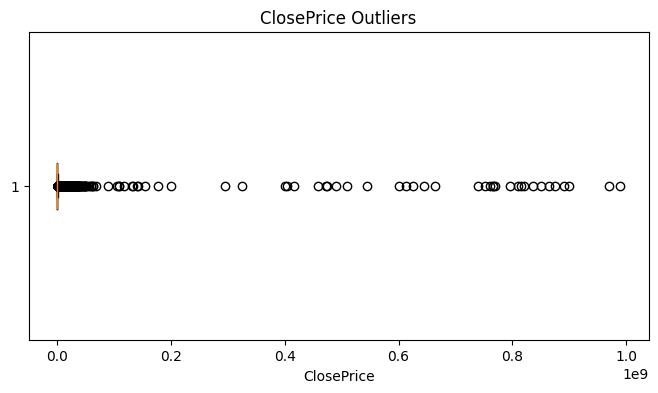

In [68]:
plt.figure(figsize=(8, 4))
plt.boxplot(sold_cleaned_df['ClosePrice'], vert=False)

plt.title('ClosePrice Outliers')
plt.xlabel('ClosePrice')

plt.show()

In [69]:
outliers_ClosePrice = sold_cleaned_df[sold_cleaned_df['ClosePrice_Outlier']]

In [70]:
outliers_ClosePrice['ClosePrice'].describe()

count    2.803200e+04
mean     5.232495e+06
std      2.457828e+07
min      2.528000e+06
25%      2.885000e+06
50%      3.445000e+06
75%      4.560000e+06
max      9.895000e+08
Name: ClosePrice, dtype: float64

(0.0, 55000000.0)

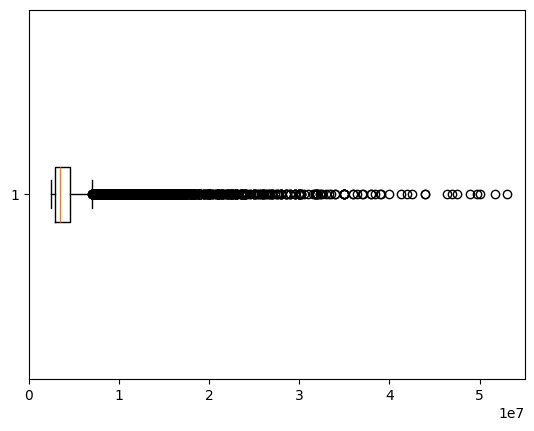

In [71]:
plt.boxplot(outliers_ClosePrice['ClosePrice'], vert=False)
plt.xlim(0, 5.5e7)

In [72]:
filtered_df_ClosePrice = sold_cleaned_df[~sold_cleaned_df['ClosePrice_Outlier']]

In [73]:
filtered_df_ClosePrice.shape

(557314, 79)

In [74]:
sold_cleaned_df['ClosePrice'].describe()

count    5.853460e+05
mean     8.865705e+05
std      5.495639e+06
min      0.000000e+00
25%      1.150000e+05
50%      6.450000e+05
75%      1.080000e+06
max      9.895000e+08
Name: ClosePrice, dtype: float64

In [75]:
filtered_df_ClosePrice['ClosePrice'].describe()

count    5.573140e+05
mean     6.679774e+05
std      5.827299e+05
min      0.000000e+00
25%      3.000000e+04
50%      6.100000e+05
75%      9.750000e+05
max      2.527000e+06
Name: ClosePrice, dtype: float64

<Axes: >

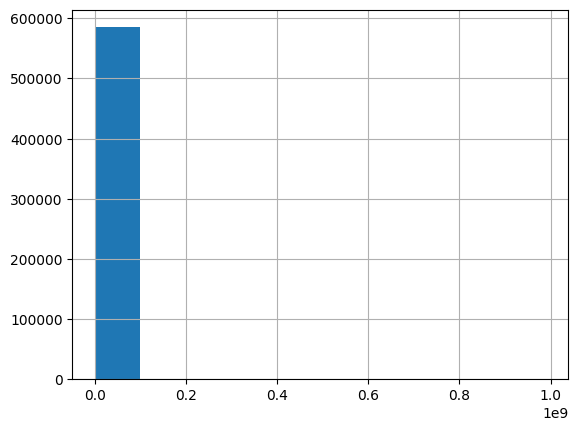

In [76]:
(sold_cleaned_df['ClosePrice']).hist()

<Axes: >

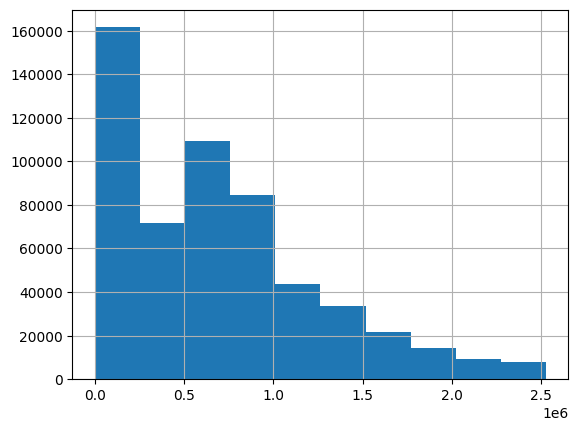

In [77]:
(filtered_df_ClosePrice['ClosePrice']).hist()

In [78]:
filtered_2_ClosePrice = sold_cleaned_df[sold_cleaned_df['ClosePrice'] < 5.5e7]

In [79]:
filtered_2_ClosePrice.shape

(585294, 79)

<Axes: >

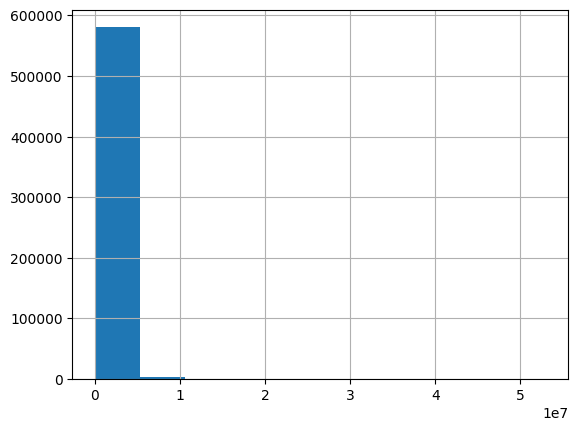

In [80]:
(filtered_2_ClosePrice['ClosePrice']).hist()

In [81]:
print(sold_cleaned_df['ClosePrice'].mean())
print(filtered_df_ClosePrice['ClosePrice'].mean())
print(filtered_2_ClosePrice['ClosePrice'].mean())

886570.4656654698
667977.4380466487
844119.7909502233


In [82]:
sold_cleaned_df = sold_cleaned_df[sold_cleaned_df['ClosePrice'] < 5.5e7]

In [83]:
sold_cleaned_df.shape

(585294, 79)

Square Footage

In [84]:
sold_cleaned_df[sold_cleaned_df['LivingArea_Outlier'] == True].shape

(29573, 79)

In [85]:
sold_cleaned_df[sold_cleaned_df['LivingArea'].notna()].shape

(585294, 79)

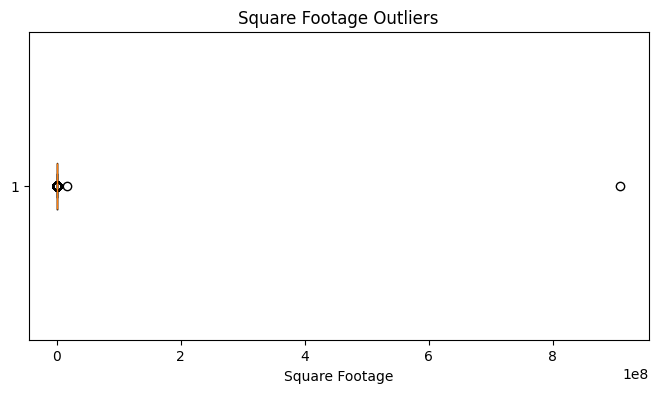

In [86]:
plt.figure(figsize=(8, 4))
plt.boxplot(sold_cleaned_df['LivingArea'], vert=False)

plt.title('Square Footage Outliers')
plt.xlabel('Square Footage')

plt.show()

In [87]:
outliers_SqFt = sold_cleaned_df[sold_cleaned_df['LivingArea_Outlier']]

In [88]:
outliers_SqFt['LivingArea'].describe()

count    2.957300e+04
mean     3.624174e+04
std      5.287291e+06
min      3.486000e+03
25%      3.766000e+03
50%      4.184000e+03
75%      5.061000e+03
max      9.090909e+08
Name: LivingArea, dtype: float64

(0.0, 150000.0)

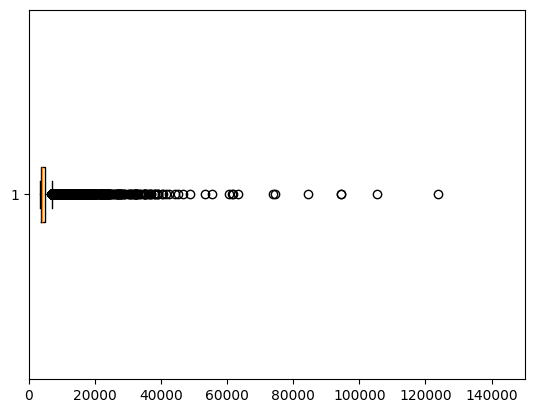

In [89]:
plt.boxplot(outliers_SqFt['LivingArea'], vert=False)
plt.xlim(0, 1.5e5)

In [90]:
filtered_df_SqFt = sold_cleaned_df[~sold_cleaned_df['LivingArea_Outlier']]

In [91]:
filtered_df_SqFt.shape

(555721, 79)

In [92]:
sold_cleaned_df['LivingArea'].describe()

count    5.852940e+05
mean     3.382949e+03
std      1.188491e+06
min      0.000000e+00
25%      1.200000e+03
50%      1.578000e+03
75%      2.114000e+03
max      9.090909e+08
Name: LivingArea, dtype: float64

In [93]:
filtered_df_SqFt['LivingArea'].describe()

count    555721.000000
mean       1634.350345
std         639.754850
min           0.000000
25%        1177.000000
50%        1570.000000
75%        2000.000000
max        3485.000000
Name: LivingArea, dtype: float64

<Axes: >

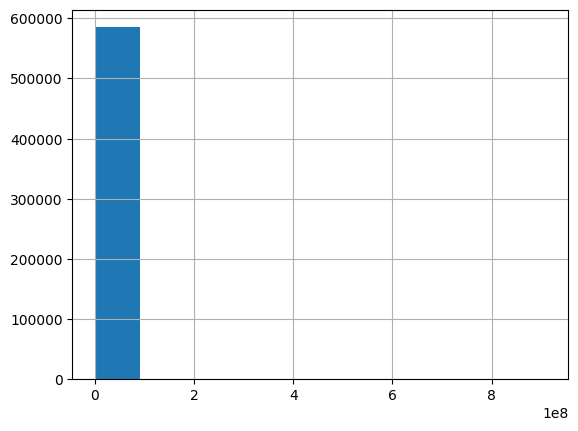

In [94]:
(sold_cleaned_df['LivingArea']).hist()

<Axes: >

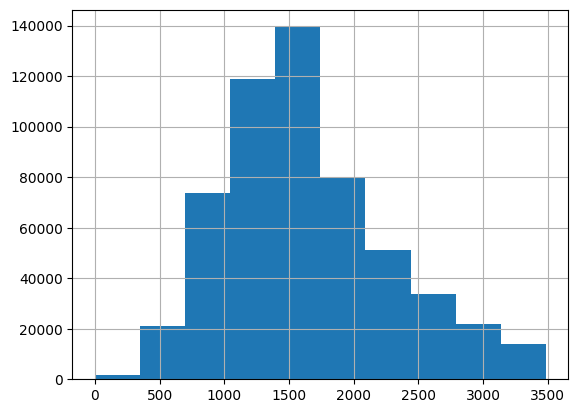

In [95]:
(filtered_df_SqFt['LivingArea']).hist()

In [96]:
sold_cleaned_df.shape[0] - filtered_df_SqFt.shape[0]

29573

In [97]:
filtered_2_SqFt = sold_cleaned_df[sold_cleaned_df['LivingArea'] < 1.5e5]
filtered_2_SqFt.shape

(585288, 79)

In [98]:
filtered_2_SqFt['LivingArea'].describe()

count    585288.000000
mean       1799.065816
std        1142.520060
min           0.000000
25%        1200.000000
50%        1578.000000
75%        2114.000000
max      123764.000000
Name: LivingArea, dtype: float64

<Axes: >

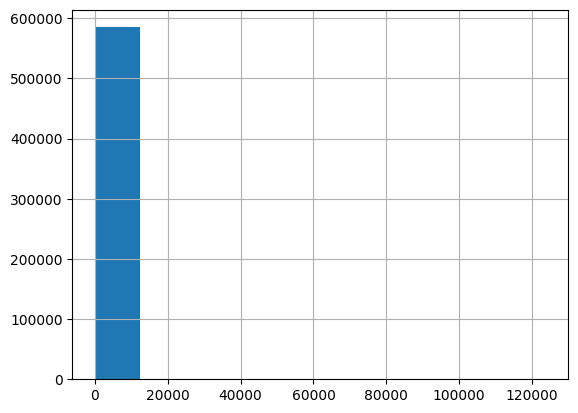

In [99]:
(filtered_2_SqFt['LivingArea']).hist()

In [100]:
print(sold_cleaned_df['LivingArea'].mean())
print(filtered_df_SqFt['LivingArea'].mean())
print(filtered_2_SqFt['LivingArea'].mean())

3382.948921499281
1634.3503452091968
1799.0658155643032


In [101]:
sold_cleaned_df = sold_cleaned_df[sold_cleaned_df['LivingArea'] < 1.5e5]
sold_cleaned_df.shape

(585288, 79)

DaysOnMarket

In [102]:
sold_cleaned_df[sold_cleaned_df['DaysOnMarket_Outlier'] == True].shape

(40365, 79)

In [103]:
sold_cleaned_df[sold_cleaned_df['DaysOnMarket'].notna()].shape

(585288, 79)

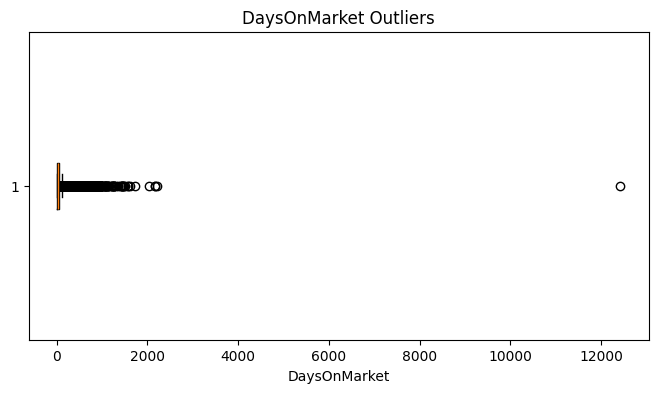

In [104]:
plt.figure(figsize=(8, 4))
plt.boxplot(sold_cleaned_df['DaysOnMarket'], vert=False)

plt.title('DaysOnMarket Outliers')
plt.xlabel('DaysOnMarket')

plt.show()

In [105]:
outliers_DaysOnMarket = sold_cleaned_df[sold_cleaned_df['DaysOnMarket_Outlier']]

In [106]:
sold_cleaned_df['DaysOnMarket'].describe()

count    585288.000000
mean         40.144281
std          56.497812
min           0.000000
25%           8.000000
50%          21.000000
75%          52.000000
max       12430.000000
Name: DaysOnMarket, dtype: float64

(0.0, 2000.0)

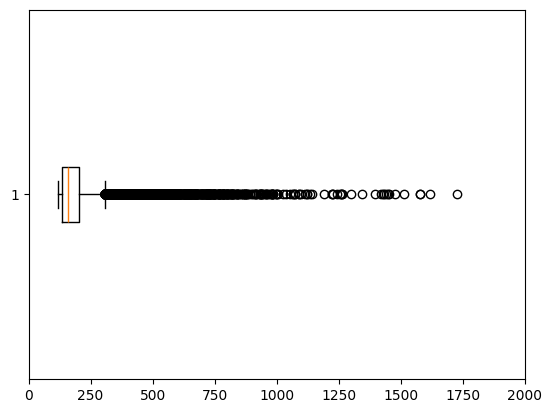

In [111]:
plt.boxplot(outliers_DaysOnMarket['DaysOnMarket'], vert=False)
plt.xlim(0, 2000)

In [112]:
filtered_df_DaysOnMarket = sold_cleaned_df[~sold_cleaned_df['DaysOnMarket_Outlier']]

In [113]:
filtered_df_DaysOnMarket.shape

(544923, 79)

In [114]:
sold_cleaned_df['DaysOnMarket'].describe()

count    585288.000000
mean         40.144281
std          56.497812
min           0.000000
25%           8.000000
50%          21.000000
75%          52.000000
max       12430.000000
Name: DaysOnMarket, dtype: float64

In [115]:
filtered_df_DaysOnMarket['DaysOnMarket'].describe()

count    544923.000000
mean         29.211551
std          27.740891
min           0.000000
25%           8.000000
50%          19.000000
75%          43.000000
max         118.000000
Name: DaysOnMarket, dtype: float64

<Axes: >

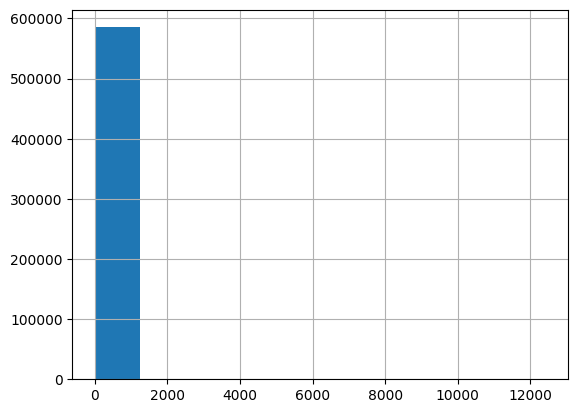

In [116]:
(sold_cleaned_df['DaysOnMarket']).hist()

<Axes: >

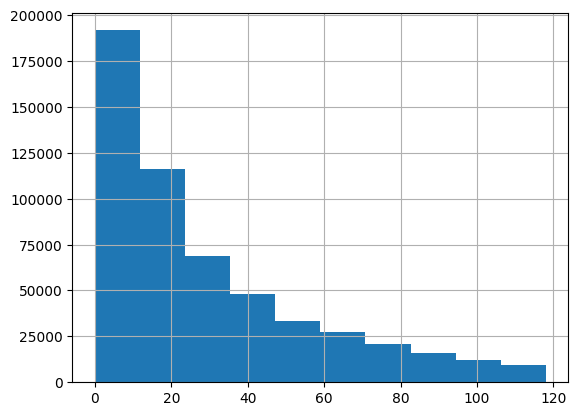

In [117]:
(filtered_df_DaysOnMarket['DaysOnMarket']).hist()

In [118]:
filtered_2_DaysOnMarket = sold_cleaned_df[sold_cleaned_df['DaysOnMarket'] < 2000]
filtered_2_DaysOnMarket.shape

(585283, 79)

In [119]:
sold_cleaned_df.shape[0] - filtered_2_DaysOnMarket.shape[0]

5

<Axes: >

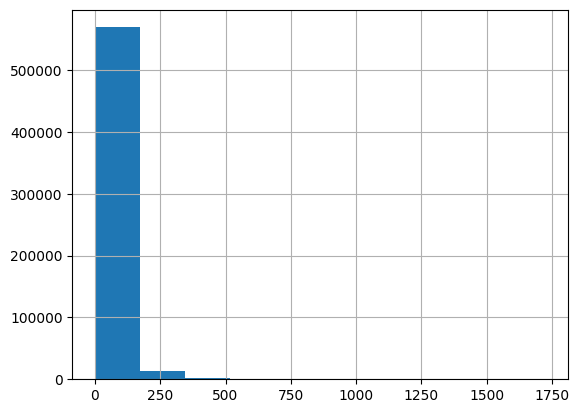

In [120]:
(filtered_2_DaysOnMarket['DaysOnMarket']).hist()

In [121]:
print(sold_cleaned_df['DaysOnMarket'].mean())
print(filtered_df_DaysOnMarket['DaysOnMarket'].mean())
print(filtered_2_DaysOnMarket['DaysOnMarket'].mean())

40.144281106053775
29.211550989772867
40.10869784360728


In [122]:
sold_cleaned_df = sold_cleaned_df[sold_cleaned_df['DaysOnMarket'] < 2000]

In [124]:
sold_cleaned_df.shape

(585283, 79)

In [252]:
df_sold_clean = sold_cleaned_df.copy()

In [255]:
df_sold_clean = df_sold_clean.drop(columns=['ClosePrice_Outlier', 'LivingArea_Outlier',
       'DaysOnMarket_Outlier'])

In [257]:
sold_cleaned_df.shape

(585283, 79)

In [258]:
df_sold_clean.shape

(585283, 76)

#### **Further Handling Missing Values Appropriately**

In [259]:
missing_sold_counts = df_sold_clean.isnull().sum()
missing_sold_counts

BuyerAgentAOR                   0
ListAgentAOR                    0
Flooring                        0
ViewYN                          0
PoolPrivateYN                   0
                            ...  
Month                           0
YrMo                            0
CloseToOriginalListRatio        0
ListingToContractDays       12199
ContractToCloseDays         12199
Length: 76, dtype: int64

In [260]:
missing_sold_percent = (df_sold_clean.isnull().mean()) * 100
missing_sold_percent

BuyerAgentAOR               0.000000
ListAgentAOR                0.000000
Flooring                    0.000000
ViewYN                      0.000000
PoolPrivateYN               0.000000
                              ...   
Month                       0.000000
YrMo                        0.000000
CloseToOriginalListRatio    0.000000
ListingToContractDays       2.084291
ContractToCloseDays         2.084291
Length: 76, dtype: float64

In [261]:
missing_summary = pd.DataFrame({
    "missing_sold_counts": missing_sold_counts,
    "missing_sold_percent": missing_sold_percent
})

In [262]:
missing_sold_summary = missing_summary.sort_values(by="missing_sold_percent", ascending=False)
print(missing_sold_summary)

                          missing_sold_counts  missing_sold_percent
ListingToContractDays                   12199              2.084291
ContractToCloseDays                     12199              2.084291
PurchaseContractDate                    12199              2.084291
ListAgentEmail                           2204              0.376570
price_per_sqft                              1              0.000171
...                                       ...                   ...
negative_timeline_flag                      0              0.000000
Month                                       0              0.000000
price_ratio                                 0              0.000000
CloseToOriginalListRatio                    0              0.000000
YrMo                                        0              0.000000

[76 rows x 2 columns]


In [263]:
missing_sold_summary[missing_sold_summary['missing_sold_percent'] > 0]

,missing_sold_counts,missing_sold_percent
ListingToContractDays,12199,2.084291
ContractToCloseDays,12199,2.084291
PurchaseContractDate,12199,2.084291
ListAgentEmail,2204,0.376570
price_per_sqft,1,0.000171


- Under 10% missing -> simple statistical imputation method, but for categorical variables, may include a "Missing" category if deemed necessary
- 10-50% missing -> "Decision Zone" - meaning that there are different approaches that can be taken to impute the missing values like a group-based imputation, model-based if justifiable, adding a missing indicator, or doing simple imputation if necessary
- above 50% -> Since at this point, they are probably important features, the missingness in the data could be important and signals themselves. 

Let's start with "Under 10% missing"

In [264]:
under_10 = missing_sold_summary[(missing_sold_summary['missing_sold_percent'] < 10) & (missing_sold_percent != 0)]

C:\Users\mayab\AppData\Local\Temp\ipykernel_9620\637377579.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  under_10 = missing_sold_summary[(missing_sold_summary['missing_sold_percent'] < 10) & (missing_sold_percent != 0)]


In [265]:
under_10

,missing_sold_counts,missing_sold_percent
ListingToContractDays,12199,2.084291
ContractToCloseDays,12199,2.084291
PurchaseContractDate,12199,2.084291
ListAgentEmail,2204,0.376570
price_per_sqft,1,0.000171


In [266]:
df_sold_clean['GarageSpaces'].value_counts().head()

GarageSpaces
2.0    368366
0.0     84165
1.0     65164
3.0     55476
4.0      7584
Name: count, dtype: int64

In [267]:
df_sold_clean['GarageSpaces'].value_counts(normalize=True).head()

GarageSpaces
2.0    0.629381
0.0    0.143802
1.0    0.111338
3.0    0.094785
4.0    0.012958
Name: proportion, dtype: float64

In [268]:
df_sold_clean['GarageSpaces_Missing'] = df_sold_clean['GarageSpaces'].isna().astype(int)

In [269]:
df_sold_clean['GarageSpaces'] = df_sold_clean['GarageSpaces'].fillna(df_sold_clean['GarageSpaces'].median())

In [270]:
df_sold_clean['GarageSpaces'].value_counts().head()

GarageSpaces
2.0    368366
0.0     84165
1.0     65164
3.0     55476
4.0      7584
Name: count, dtype: int64

In [271]:
df_sold_clean['GarageSpaces'].value_counts(normalize=True).head()

GarageSpaces
2.0    0.629381
0.0    0.143802
1.0    0.111338
3.0    0.094785
4.0    0.012958
Name: proportion, dtype: float64

In [272]:
df_sold_clean['LotSizeAcres'].describe()

count    5.852830e+05
mean     6.965107e+02
std      4.841583e+05
min      0.000000e+00
25%      1.240000e-01
50%      1.653000e-01
75%      2.500000e-01
max      3.702600e+08
Name: LotSizeAcres, dtype: float64

In [273]:
df_sold_clean['LotSizeAcres'] = df_sold_clean['LotSizeAcres'].fillna(df_sold_clean['LotSizeAcres'].median())

In [274]:
df_sold_clean['LotSizeAcres'].isna().sum()

np.int64(0)

The mean is greater than the median. The values are skewed to the right. I will be using the median to impute.

In [275]:
df_sold_clean['ViewYN'].value_counts()

ViewYN
True     375735
False    209548
Name: count, dtype: int64

In [276]:
df_sold_clean['ViewYN'].value_counts(normalize=True)

ViewYN
True     0.641971
False    0.358029
Name: proportion, dtype: float64

In [277]:
df_sold_clean['ViewYN'] = df_sold_clean['ViewYN'].fillna(df_sold_clean['ViewYN'].mode()[0])

In [278]:
df_sold_clean['ViewYN'].value_counts(normalize=True)

ViewYN
True     0.641971
False    0.358029
Name: proportion, dtype: float64

In [279]:
df_sold_clean['LotSizeSquareFeet'].describe()

count    5.852830e+05
mean     4.141931e+05
std      1.936472e+07
min      0.000000e+00
25%      5.356000e+03
50%      7.200000e+03
75%      1.088900e+04
max      5.193920e+09
Name: LotSizeSquareFeet, dtype: float64

The mean is less than the median. The values are skewed to the left. I will be using the median to impute the missing values. 

In [280]:
df_sold_clean['LotSizeSquareFeet'] = df_sold_clean['LotSizeSquareFeet'].fillna(df_sold_clean['LotSizeSquareFeet'].median())

In [281]:
df_sold_clean['LotSizeSquareFeet'].isna().sum()

np.int64(0)

In [282]:
df_sold_clean['LotSizeArea'].describe()

count    5.852830e+05
mean     4.123184e+04
std      2.217038e+06
min      0.000000e+00
25%      5.120000e+03
50%      7.000000e+03
75%      1.010300e+04
max      9.187423e+08
Name: LotSizeArea, dtype: float64

The mean is less than the median. The values are skewed to the left. I will be using the median to impute.

In [283]:
df_sold_clean['LotSizeArea'] = df_sold_clean['LotSizeArea'].fillna(df_sold_clean['LotSizeArea'].median())

In [284]:
df_sold_clean['LotSizeArea'].isna().sum()

np.int64(0)

In [285]:
df_sold_clean['PoolPrivateYN'].value_counts()

PoolPrivateYN
False    522469
True      62814
Name: count, dtype: int64

In [286]:
df_sold_clean['PoolPrivateYN'].value_counts(normalize=True)

PoolPrivateYN
False    0.892678
True     0.107322
Name: proportion, dtype: float64

In [287]:
df_sold_clean['PoolPrivateYN'] = df_sold_clean['PoolPrivateYN'].fillna(df_sold_clean['PoolPrivateYN'].mode()[0])

In [288]:
df_sold_clean['PoolPrivateYN'].value_counts(normalize=True)

PoolPrivateYN
False    0.892678
True     0.107322
Name: proportion, dtype: float64

In [289]:
df_sold_clean['FireplaceYN'].value_counts()

FireplaceYN
True     371952
False    213331
Name: count, dtype: int64

In [290]:
df_sold_clean['FireplaceYN'].value_counts(normalize=True)

FireplaceYN
True     0.635508
False    0.364492
Name: proportion, dtype: float64

In [291]:
df_sold_clean['FireplaceYN'] = df_sold_clean['FireplaceYN'].fillna(df_sold_clean['FireplaceYN'].mode()[0])

In [292]:
df_sold_clean['FireplaceYN'].value_counts(normalize=True)

FireplaceYN
True     0.635508
False    0.364492
Name: proportion, dtype: float64

In [293]:
df_sold_clean['PropertySubType'].value_counts().head()

PropertySubType
SingleFamilyResidence    400147
Condominium              105565
Townhouse                 34835
Apartment                 13857
Duplex                    11475
Name: count, dtype: int64

In [294]:
df_sold_clean['PropertySubType'].value_counts(normalize=True).head()

PropertySubType
SingleFamilyResidence    0.683681
Condominium              0.180366
Townhouse                0.059518
Apartment                0.023676
Duplex                   0.019606
Name: proportion, dtype: float64

In [295]:
df_sold_clean['PropertySubType'] = df_sold_clean['PropertySubType'].fillna(df_sold_clean['PropertySubType'].mode()[0])

In [296]:
df_sold_clean['PropertySubType'].value_counts(normalize=True).head()

PropertySubType
SingleFamilyResidence    0.683681
Condominium              0.180366
Townhouse                0.059518
Apartment                0.023676
Duplex                   0.019606
Name: proportion, dtype: float64

In [297]:
df_sold_clean['BuyerOfficeAOR'].value_counts(normalize=True).head()

BuyerOfficeAOR
OrangeCounty    0.093093
PacificWest     0.065743
SanDiego        0.063269
Southland       0.056732
Missing         0.045060
Name: proportion, dtype: float64

In [298]:
df_sold_clean['BuyerOfficeAOR'] = df_sold_clean['BuyerOfficeAOR'].fillna("Missing")

In [299]:
df_sold_clean['BuyerOfficeAOR'].value_counts(normalize=True).head()

BuyerOfficeAOR
OrangeCounty    0.093093
PacificWest     0.065743
SanDiego        0.063269
Southland       0.056732
Missing         0.045060
Name: proportion, dtype: float64

In [300]:
df_sold_clean['LivingArea'].describe()

count    585283.000000
mean       1799.041862
std        1142.385480
min           0.000000
25%        1200.000000
50%        1578.000000
75%        2114.000000
max      123764.000000
Name: LivingArea, dtype: float64

The mean is greater than the median, which shows that it is skewing to the right. I will then impute by the median rather than the mean.

In [301]:
df_sold_clean['LivingArea'] = df_sold_clean['LivingArea'].fillna(df_sold_clean['LivingArea'].median())

In [302]:
df_sold_clean['LivingArea'].describe()

count    585283.000000
mean       1799.041862
std        1142.385480
min           0.000000
25%        1200.000000
50%        1578.000000
75%        2114.000000
max      123764.000000
Name: LivingArea, dtype: float64

In [303]:
df_sold_clean['LivingArea'].isna().sum()

np.int64(0)

In [304]:
df_sold_clean['BedroomsTotal'].value_counts().head()

BedroomsTotal
3.0    231604
4.0    133447
2.0    132992
5.0     38834
1.0     33269
Name: count, dtype: int64

In [305]:
df_sold_clean['BedroomsTotal'].value_counts(normalize=True).head()

BedroomsTotal
3.0    0.395713
4.0    0.228004
2.0    0.227227
5.0    0.066351
1.0    0.056843
Name: proportion, dtype: float64

In [306]:
df_sold_clean['BedroomsTotal_Missing'] = df_sold_clean['BedroomsTotal'].isna().astype(int)

In [307]:
df_sold_clean['BedroomsTotal'] = df_sold_clean['BedroomsTotal'].fillna(df_sold_clean['BedroomsTotal'].median())

In [308]:
df_sold_clean['BedroomsTotal'].isna().sum()

np.int64(0)

In [309]:
df_sold_clean['Latitude'].describe()

count    585283.000000
mean         34.483073
std           1.547570
min        -117.472493
25%          33.740870
50%          34.040754
75%          34.396547
max         157.000000
Name: Latitude, dtype: float64

The median and the mean are about the same measure, so I will use the mean to impute missing values.

In [310]:
df_sold_clean['Latitude'] = df_sold_clean['Latitude'].fillna(df_sold_clean['Latitude'].mean())

In [311]:
df_sold_clean['Latitude'].isna().sum()

np.int64(0)

In [312]:
df_sold_clean['Longitude'].describe()

count    585283.000000
mean       -118.429346
std           2.897932
min        -177.646696
25%        -118.493004
50%        -118.082170
75%        -117.354778
max         329.000000
Name: Longitude, dtype: float64

The median and the mean are about the same measure, so I will use the mean to impute missing values.

In [313]:
df_sold_clean['Longitude'] = df_sold_clean['Longitude'].fillna(df_sold_clean['Longitude'].mean())

In [314]:
df_sold_clean['Longitude'].isna().sum()

np.int64(0)

In [315]:
df_sold_clean['PurchaseContractDate'].isna().sum()

np.int64(12199)

In [316]:
df_sold_clean['No_Purchase_Date'] = df_sold_clean['PurchaseContractDate'].isna()

In [317]:
df_sold_clean['YearBuilt'].describe()

count    585283.000000
mean       1978.205853
std          26.847914
min        1776.000000
25%        1960.000000
50%        1978.000000
75%        1999.000000
max        2026.000000
Name: YearBuilt, dtype: float64

The mean and the median are about the same

In [318]:
df_sold_clean['YearBuilt'] = df_sold_clean['YearBuilt'].fillna(round(df_sold_clean['YearBuilt'].mean()))

In [319]:
(df_sold_clean['YearBuilt'] % 1 == 0).value_counts()

YearBuilt
True    585283
Name: count, dtype: int64

In [320]:
df_sold_clean['BathroomsTotalInteger'].describe()

count    585283.000000
mean          2.442666
std           1.413349
min           0.000000
25%           2.000000
50%           2.000000
75%           3.000000
max         175.000000
Name: BathroomsTotalInteger, dtype: float64

In [321]:
df_sold_clean['BathroomsTotalInteger'].value_counts(normalize=True).head()

BathroomsTotalInteger
2.0    0.425480
3.0    0.303412
1.0    0.138287
4.0    0.069262
5.0    0.025099
Name: proportion, dtype: float64

In [322]:
df_sold_clean['BathroomsTotalInteger'] = df_sold_clean['BathroomsTotalInteger'].fillna(round(df_sold_clean['BathroomsTotalInteger'].mean()))

In [323]:
df_sold_clean['BathroomsTotalInteger'].value_counts(normalize=True).head()

BathroomsTotalInteger
2.0    0.425480
3.0    0.303412
1.0    0.138287
4.0    0.069262
5.0    0.025099
Name: proportion, dtype: float64

In [324]:
df_sold_clean['BuyerOfficeName'].value_counts(normalize=True).head()

BuyerOfficeName
Compass                   0.061524
Coldwell Banker Realty    0.036915
NONMEMBER MRML            0.019778
None MRML                 0.014214
Keller Williams Realty    0.014173
Name: proportion, dtype: float64

In [325]:
df_sold_clean['BuyerOfficeName'] = df_sold_clean['BuyerOfficeName'].fillna("Missing")

In [326]:
df_sold_clean['BuyerOfficeName'].value_counts(normalize=True).head()

BuyerOfficeName
Compass                   0.061524
Coldwell Banker Realty    0.036915
NONMEMBER MRML            0.019778
None MRML                 0.014214
Keller Williams Realty    0.014173
Name: proportion, dtype: float64

In [327]:
df_sold_clean['BuyerOfficeName'].isna().sum()

np.int64(0)

Onto the 10-50% missing

In [328]:
btwn_10_50 = missing_sold_summary[(missing_sold_summary['missing_sold_percent'] >= 10) & (missing_sold_percent <= 50)]

C:\Users\mayab\AppData\Local\Temp\ipykernel_9620\1507415290.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  btwn_10_50 = missing_sold_summary[(missing_sold_summary['missing_sold_percent'] >= 10) & (missing_sold_percent <= 50)]


In [329]:
btwn_10_50

,missing_sold_counts,missing_sold_percent


In [330]:
df_sold_clean['MainLevelBedrooms'].describe()

count    585283.000000
mean          1.961885
std           4.580921
min           0.000000
25%           2.000000
50%           2.000000
75%           2.000000
max        3333.000000
Name: MainLevelBedrooms, dtype: float64

In [331]:
df_sold_clean['MainLevelBedrooms'].value_counts(normalize=True).head()

MainLevelBedrooms
2.0    0.550819
3.0    0.139681
1.0    0.138260
0.0    0.101795
4.0    0.059385
Name: proportion, dtype: float64

In [332]:
df_sold_clean['MainLevelBedrooms_Missing'] = df_sold_clean['MainLevelBedrooms'].isna().astype(int)

In [333]:
df_sold_clean['MainLevelBedrooms'] = df_sold_clean['MainLevelBedrooms'].fillna(df_sold_clean['MainLevelBedrooms'].median())

In [334]:
df_sold_clean['MainLevelBedrooms'].value_counts(normalize=True).head()

MainLevelBedrooms
2.0    0.550819
3.0    0.139681
1.0    0.138260
0.0    0.101795
4.0    0.059385
Name: proportion, dtype: float64

The mean and the median is about the same, so using mean to impute the missing values but also add a missing indicator.

In [335]:
df_sold_clean['MainLevelBedrooms'].isna().sum()

np.int64(0)

In [336]:
df_sold_clean['Flooring'].value_counts(normalize=True).head()

Flooring
Missing        0.394044
Wood           0.067957
Laminate       0.066315
Carpet,Tile    0.059915
Tile,Wood      0.046456
Name: proportion, dtype: float64

In [337]:
df_sold_clean['Flooring'] = df_sold_clean['Flooring'].fillna("Missing")

In [338]:
df_sold_clean['Flooring'].value_counts().head()

Flooring
Missing        230627
Wood            39774
Laminate        38813
Carpet,Tile     35067
Tile,Wood       27190
Name: count, dtype: int64

In [339]:
df_sold_clean['Flooring'].isna().sum()

np.int64(0)

In [340]:
df_sold_clean['HighSchoolDistrict'].value_counts().head()

HighSchoolDistrict
Missing                183681
Los Angeles Unified     38753
Other                   33059
Capistrano Unified      15035
Irvine Unified          10128
Name: count, dtype: int64

In [341]:
df_sold_clean['HighSchoolDistrict'] = df_sold_clean['HighSchoolDistrict'].fillna("Missing")

In [342]:
df_sold_clean['HighSchoolDistrict'].value_counts().head()

HighSchoolDistrict
Missing                183681
Los Angeles Unified     38753
Other                   33059
Capistrano Unified      15035
Irvine Unified          10128
Name: count, dtype: int64

In [343]:
df_sold_clean['AssociationFee'].describe()

count    585283.000000
mean        203.309055
std        1402.767462
min           0.000000
25%           0.000000
50%          85.675856
75%         277.000000
max      750000.000000
Name: AssociationFee, dtype: float64

In [344]:
# Regression Predictions
def impute_lgbm_numeric(df, target):
    df = df.copy()

    # mask missing values
    missing_mask = df[target].isna()

    if missing_mask.sum() == 0:
        return df

    # split data
    train = df[~missing_mask]
    test = df[missing_mask]

    y_train = train[target]
    X_train = train.drop(columns=[target]).select_dtypes(include='number')
    X_test = test.drop(columns=[target]).select_dtypes(include='number')

    # encode categorical columns safely
    for col in X_train.select_dtypes(include=['object', 'category']).columns:
        X_train[col] = X_train[col].astype('category').cat.codes
        X_test[col] = X_test[col].astype('category').cat.codes

    # model
    model = LGBMRegressor(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42,
        verbosity=-1
    )

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    # constraint: association_fee cannot be negative
    preds = np.clip(preds, a_min=0, a_max=None)

    df.loc[missing_mask, target] = preds

    return df

In [345]:
df_sold_clean = impute_lgbm_numeric(df_sold_clean, "AssociationFee")

In [346]:
df_sold_clean['AssociationFee'].describe()

count    585283.000000
mean        203.309055
std        1402.767462
min           0.000000
25%           0.000000
50%          85.675856
75%         277.000000
max      750000.000000
Name: AssociationFee, dtype: float64

In [347]:
df_sold_clean['AssociationFee'].isna().sum()

np.int64(0)

In [348]:
(df_sold_clean['AssociationFee'] < 0).value_counts()

AssociationFee
False    585283
Name: count, dtype: int64

In [349]:
df_sold_clean['AttachedGarageYN'].value_counts()

AttachedGarageYN
True       339908
Missing    149382
False       95993
Name: count, dtype: int64

In [350]:
df_sold_clean['AttachedGarageYN'] = df_sold_clean['AttachedGarageYN'].fillna("Missing")

In [351]:
df_sold_clean['AttachedGarageYN'].value_counts()

AttachedGarageYN
True       339908
Missing    149382
False       95993
Name: count, dtype: int64

In [352]:
df_sold_clean['Stories'].describe()

count    585283.000000
mean          1.304547
std           0.460216
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max           2.000000
Name: Stories, dtype: float64

In [353]:
df_sold_clean['Stories'].value_counts()

Stories
1.0    407037
2.0    178246
Name: count, dtype: int64

In [354]:
df_sold_clean['Stories'].value_counts(normalize=True)

Stories
1.0    0.695453
2.0    0.304547
Name: proportion, dtype: float64

In [355]:
df_sold_clean['Stories_Missing'] = df_sold_clean['Stories'].isna().astype(int)

In [356]:
df_sold_clean['Stories'] = df_sold_clean['Stories'].fillna(df_sold_clean['Stories'].median())

In [357]:
df_sold_clean['Stories'].value_counts()

Stories
1.0    407037
2.0    178246
Name: count, dtype: int64

In [358]:
df_sold_clean['Stories'].value_counts(normalize=True)

Stories
1.0    0.695453
2.0    0.304547
Name: proportion, dtype: float64

In [359]:
df_sold_clean['BuyerAgentAOR'].value_counts().head()

BuyerAgentAOR
Missing                  69722
OrangeCounty             51774
BeverlyHillsGreaterLa    35801
PacificWest              34944
SanDiego                 33046
Name: count, dtype: int64

In [360]:
df_sold_clean['BuyerAgentAOR'] = df_sold_clean['BuyerAgentAOR'].fillna("Missing")

In [361]:
df_sold_clean['BuyerAgentAOR'].value_counts().head()

BuyerAgentAOR
Missing                  69722
OrangeCounty             51774
BeverlyHillsGreaterLa    35801
PacificWest              34944
SanDiego                 33046
Name: count, dtype: int64

In [362]:
df_sold_clean['ListAgentAOR'].value_counts().head()

ListAgentAOR
Missing                  64279
OrangeCounty             52480
BeverlyHillsGreaterLa    35934
PacificWest              35266
Southland                33551
Name: count, dtype: int64

In [363]:
df_sold_clean['ListAgentAOR'] = df_sold_clean['ListAgentAOR'].fillna("Missing")

In [364]:
df_sold_clean['ListAgentAOR'].value_counts().head()

ListAgentAOR
Missing                  64279
OrangeCounty             52480
BeverlyHillsGreaterLa    35934
PacificWest              35266
Southland                33551
Name: count, dtype: int64

In [365]:
df_sold_clean['NewConstructionYN'].value_counts()

NewConstructionYN
False    563926
True      21357
Name: count, dtype: int64

In [366]:
df_sold_clean['NewConstructionYN'].value_counts(normalize=True)

NewConstructionYN
False    0.96351
True     0.03649
Name: proportion, dtype: float64

In [367]:
df_sold_clean['NewConstructionYN'] = df_sold_clean['NewConstructionYN'].fillna(df_sold_clean['NewConstructionYN'].mode()[0])

In [368]:
df_sold_clean['NewConstructionYN'].value_counts(normalize=True)

NewConstructionYN
False    0.96351
True     0.03649
Name: proportion, dtype: float64

In [369]:
df_sold_clean['MLSAreaMajor'].value_counts().head()

MLSAreaMajor
Missing                               63619
699 - Not Defined                     48810
SRCAR - Southwest Riverside County    24929
252 - Riverside                        6832
248 - Corona                           4422
Name: count, dtype: int64

In [370]:
df_sold_clean['MLSAreaMajor'].value_counts(normalize=True).head()

MLSAreaMajor
Missing                               0.108698
699 - Not Defined                     0.083396
SRCAR - Southwest Riverside County    0.042593
252 - Riverside                       0.011673
248 - Corona                          0.007555
Name: proportion, dtype: float64

In [371]:
df_sold_clean['MLSAreaMajor'].describe()

count      585283
unique       1115
top       Missing
freq        63619
Name: MLSAreaMajor, dtype: object

In [372]:
df_sold_clean['MLSAreaMajor'] = df_sold_clean['MLSAreaMajor'].fillna("Missing")

In [373]:
df_sold_clean['MLSAreaMajor'].value_counts(normalize=True).head()

MLSAreaMajor
Missing                               0.108698
699 - Not Defined                     0.083396
SRCAR - Southwest Riverside County    0.042593
252 - Riverside                       0.011673
248 - Corona                          0.007555
Name: proportion, dtype: float64

In [374]:
df_sold_clean['Levels'].value_counts().head()

Levels
One            307389
Two            177040
Missing         58359
ThreeOrMore     25682
MultiSplit      12013
Name: count, dtype: int64

In [375]:
df_sold_clean['Levels'].value_counts(normalize=True).head()

Levels
One            0.525197
Two            0.302486
Missing        0.099711
ThreeOrMore    0.043880
MultiSplit     0.020525
Name: proportion, dtype: float64

In [376]:
df_sold_clean['Levels'] = df_sold_clean['Levels'].fillna("Missing")

In [377]:
df_sold_clean['Levels'].value_counts(normalize=True).head()

Levels
One            0.525197
Two            0.302486
Missing        0.099711
ThreeOrMore    0.043880
MultiSplit     0.020525
Name: proportion, dtype: float64

In [378]:
df_sold_clean['Levels'].isna().sum()

np.int64(0)

Over 50% missing values

In [379]:
over_50 = missing_sold_summary[missing_sold_summary['missing_sold_percent'] >= 50]

In [380]:
over_50

,missing_sold_counts,missing_sold_percent


In [381]:
df_sold_clean['SubdivisionName'] = df_sold_clean['SubdivisionName'].fillna("Missing")

In [382]:
df_sold_clean['SubdivisionName'].value_counts(normalize=True).head()

SubdivisionName
Missing               0.636265
Other                 0.010198
Not Applicable-1      0.006289
Not Applicable        0.005442
Leisure World (LW)    0.004652
Name: proportion, dtype: float64

In [383]:
df_sold_clean.isna().sum().sort_values(ascending=False)

ListingToContractDays       12199
ContractToCloseDays         12199
PurchaseContractDate        12199
ListAgentEmail               2204
price_per_sqft                  1
                            ...  
negative_timeline_flag          0
Month                           0
price_ratio                     0
CloseToOriginalListRatio        0
YrMo                            0
Length: 76, dtype: int64

In [384]:
df_sold_clean.isna().sum().sum()

np.int64(38802)

In [385]:
df_sold_clean.isna().sum().sum() / df_sold_clean.notna().sum().sum()

np.float64(0.0008730791504909715)

In [386]:
df_sold_clean.columns

Index(['BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'ViewYN', 'PoolPrivateYN',
       'OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude',
       'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName',
       'ListAgentFullName', 'BuyerAgentMlsId', 'BuyerAgentFirstName',
       'BuyerAgentLastName', 'ListingKeyNumeric', 'MLSAreaMajor',
       'CountyOrParish', 'MlsStatus', 'AttachedGarageYN', 'ParkingTotal',
       'PropertySubType', 'LotSizeAcres', 'SubdivisionName', 'BuyerOfficeAOR',
       'YearBuilt', 'StreetNumberNumeric', 'ListingId',
       'BathroomsTotalInteger', 'City', 'BedroomsTotal',
       'ContractStatusChangeDate', 'PurchaseContractDate',
       'ListingContractDate', 'StateOrProvince', 'FireplaceYN', 'Stories',
       'Levels', 'LotSizeArea', 'MainLevelBedrooms', 'NewConstructionYN',
       'GarageSpaces

#### **Data Consistency Checks**

In [387]:
df_sold_clean['listing_after_close_flag'] = df_sold_clean['ListingContractDate'] > df_sold_clean['CloseDate']

In [388]:
df_sold_clean['listing_after_close_flag'].value_counts()

listing_after_close_flag
False    585175
True        108
Name: count, dtype: int64

In [389]:
df_sold_clean['purchase_after_close_flag'] = df_sold_clean['PurchaseContractDate'] > df_sold_clean['CloseDate']

In [390]:
df_sold_clean['purchase_after_close_flag'].value_counts()

purchase_after_close_flag
False    585159
True        124
Name: count, dtype: int64

In [391]:
df_sold_clean['negative_timeline_flag'] = (
   ( df_sold_clean['ListingContractDate'] > df_sold_clean['PurchaseContractDate']) |
   (df_sold_clean['PurchaseContractDate'] > df_sold_clean['CloseDate']) |
   (df_sold_clean['ListingContractDate'] > df_sold_clean['CloseDate'])
)

In [392]:
df_sold_clean['negative_timeline_flag'].value_counts()

negative_timeline_flag
False    584771
True        512
Name: count, dtype: int64

In [394]:
#df_sold_clean.to_csv("../data/Sold/sold_cleaned.csv", index=False)